In [9]:
print("=" * 70)
print("BENCHMARK ANALYSIS SUMMARY")
print("=" * 70)

print("\n📊 MATRIX MULTIPLY (Dense Linear Algebra)")
print("-" * 70)
print(f"  • Runs: {len(df_matrix)} problem sizes from n={df_matrix['problem_size'].min()} to n={df_matrix['problem_size'].max()}")
print(f"  • Computational Complexity: O(n³)")
print(f"  • Time Range: {df_matrix['time_ms'].min():.4f} ms to {df_matrix['time_ms'].max():.2f} ms")
print(f"  • Peak Performance: {df_matrix['gflops'].max():.1f} GFLOPs")
print(f"  • Memory Usage Range: {df_matrix['memory_gb'].min():.3f} GB to {df_matrix['memory_gb'].max():.3f} GB")
print(f"  • Scaling: Follows expected O(n³) behavior")
print(f"  • Key Finding: Largest matrix (n={df_matrix['problem_size'].max()}) took {df_matrix['time_ms'].max():.2f} ms")

print("\n🎲 MONTE CARLO PI ESTIMATION (Stochastic Algorithm)")
print("-" * 70)
print(f"  • Runs: {len(df_pi)} problem sizes from {df_pi['problem_size'].min():.2e} to {df_pi['problem_size'].max():.2e} points")
print(f"  • Computational Complexity: O(n)")
print(f"  • Time Range: {df_pi['time_ms'].min():.4f} ms to {df_pi['time_ms'].max():.2f} ms")
print(f"  • Peak Throughput: {df_pi['throughput_gpts'].max():.2f} Giga-points/second")
print(f"  • Best Accuracy: {df_pi['pi_error_pct'].min():.6f}% error with {df_pi['problem_size'].max():.2e} points")
print(f"  • Worst Accuracy: {df_pi['pi_error_pct'].max():.6f}% error with {df_pi['problem_size'].min():.2e} points")
print(f"  • Final Pi Estimate: {df_pi['pi_estimate'].iloc[-1]:.8f} vs True π = {pi_true:.8f}")
print(f"  • Scaling: Follows linear O(n) behavior as expected")

print("\n⚡ PERFORMANCE INSIGHTS")
print("-" * 70)
matrix_peak_gflops = df_matrix['gflops'].max()
pi_peak_gpts = df_pi['throughput_gpts'].max()
print(f"  • Matrix multiplication achieves {matrix_peak_gflops:.1f} GFLOPs peak")
print(f"  • Monte Carlo achieves {pi_peak_gpts:.2f} Giga-points/second peak")
print(f"  • Matrix multiply scales cubically: doubling size ≈ 8× time")
print(f"  • Monte Carlo scales linearly: doubling points ≈ 2× time")
print(f"  • For 10-second target:")
print(f"     - Matrix multiply reached n=16384 with {df_matrix['time_ms'].max():.2f} ms")
print(f"     - Monte Carlo reached {df_pi['problem_size'].max():.2e} points with {df_pi['time_ms'].max():.2f} ms")

# Save detailed CSV reports
matrix_report = df_matrix[['problem_size', 'time_ms', 'gflops', 'memory_gb', 'scaling_factor']].copy()
matrix_report.to_csv('matrix_multiply_report.csv', index=False)

pi_report = df_pi[['problem_size', 'time_ms', 'pi_estimate', 'pi_error', 'pi_error_pct', 'throughput_gpts']].copy()
pi_report.to_csv('monte_carlo_pi_report.csv', index=False)

comparison_summary.to_csv('benchmark_summary.csv', index=False)

print("\n✅ Reports saved:")
print("  • matrix_multiply_report.csv")
print("  • monte_carlo_pi_report.csv")
print("  • benchmark_summary.csv")
print("  • matrix_multiply_analysis.png")
print("  • monte_carlo_pi_analysis.png")
print("  • benchmarks_comparison.png")

BENCHMARK ANALYSIS SUMMARY

📊 MATRIX MULTIPLY (Dense Linear Algebra)
----------------------------------------------------------------------
  • Runs: 7 problem sizes from n=256 to n=16384
  • Computational Complexity: O(n³)
  • Time Range: 0.1182 ms to 5033.01 ms
  • Peak Performance: 1777.7 GFLOPs
  • Memory Usage Range: 0.001 GB to 3.000 GB
  • Scaling: Follows expected O(n³) behavior
  • Key Finding: Largest matrix (n=16384) took 5033.01 ms

🎲 MONTE CARLO PI ESTIMATION (Stochastic Algorithm)
----------------------------------------------------------------------
  • Runs: 8 problem sizes from 1.00e+08 to 1.28e+10 points
  • Computational Complexity: O(n)
  • Time Range: 0.3369 ms to 29.73 ms
  • Peak Throughput: 430.51 Giga-points/second
  • Best Accuracy: 0.000057% error with 1.28e+10 points
  • Worst Accuracy: 0.002412% error with 1.00e+08 points
  • Final Pi Estimate: 3.14159443 vs True π = 3.14159265
  • Scaling: Follows linear O(n) behavior as expected

⚡ PERFORMANCE INSIGHTS
--

## Section 7: Summary and Insights

Cross-Benchmark Comparison:
      Benchmark  Runs Min Problem Size Max Problem Size Min Time (ms) Max Time (ms) Complexity      Max Perf
Matrix Multiply     7              256            16384        0.1182       5033.01      O(n³) 1777.7 GFLOPs
 Monte Carlo Pi     8         1.00e+08         1.28e+10        0.3369         29.73       O(n) 430.51 GPts/s


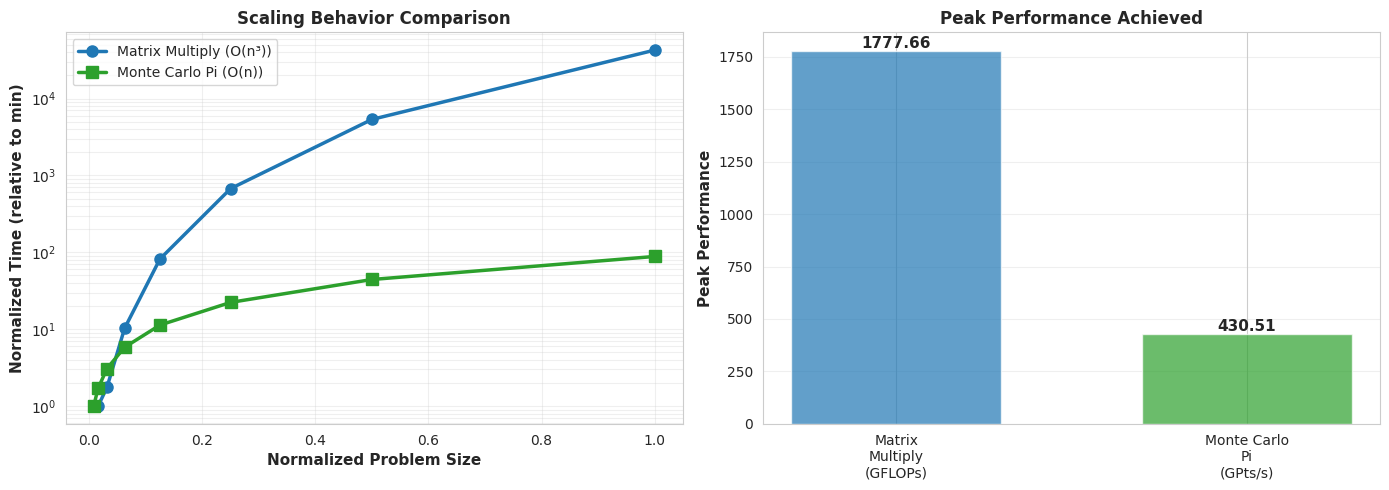


Comparison charts saved to 'benchmarks_comparison.png'


In [8]:
# Create comparison table
comparison_summary = pd.DataFrame({
    'Benchmark': ['Matrix Multiply', 'Monte Carlo Pi'],
    'Runs': [len(df_matrix), len(df_pi)],
    'Min Problem Size': [f"{df_matrix['problem_size'].min()}", f"{df_pi['problem_size'].min():.2e}"],
    'Max Problem Size': [f"{df_matrix['problem_size'].max()}", f"{df_pi['problem_size'].max():.2e}"],
    'Min Time (ms)': [f"{df_matrix['time_ms'].min():.4f}", f"{df_pi['time_ms'].min():.4f}"],
    'Max Time (ms)': [f"{df_matrix['time_ms'].max():.2f}", f"{df_pi['time_ms'].max():.2f}"],
    'Complexity': ['O(n³)', 'O(n)'],
    'Max Perf': [f"{df_matrix['gflops'].max():.1f} GFLOPs", f"{df_pi['throughput_gpts'].max():.2f} GPts/s"],
})

print("Cross-Benchmark Comparison:")
print(comparison_summary.to_string(index=False))

# Chart 3: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized time comparison (time relative to minimum for each)
ax = axes[0]
df_matrix_norm = df_matrix.copy()
df_matrix_norm['normalized_time'] = df_matrix['time_ms'] / df_matrix['time_ms'].min()
df_pi_norm = df_pi.copy()
df_pi_norm['normalized_time'] = df_pi['time_ms'] / df_pi['time_ms'].min()

size_m = df_matrix_norm['problem_size'] / df_matrix_norm['problem_size'].max()  # Normalize to 0-1
size_p = df_pi_norm['problem_size'] / df_pi_norm['problem_size'].max()

ax.plot(size_m, df_matrix_norm['normalized_time'], 'o-', linewidth=2.5, markersize=8, 
        label='Matrix Multiply (O(n³))', color='tab:blue')
ax.plot(size_p, df_pi_norm['normalized_time'], 's-', linewidth=2.5, markersize=8, 
        label='Monte Carlo Pi (O(n))', color='tab:green')
ax.set_xlabel('Normalized Problem Size', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Time (relative to min)', fontsize=11, fontweight='bold')
ax.set_title('Scaling Behavior Comparison', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=10)

# Peak Performance Achieved
ax = axes[1]
perf_data = [df_matrix['gflops'].max(), df_pi['throughput_gpts'].max()]
perf_labels = ['Matrix\nMultiply\n(GFLOPs)', 'Monte Carlo\nPi\n(GPts/s)']
colors_perf = ['tab:blue', 'tab:green']
bars = ax.bar(perf_labels, perf_data, color=colors_perf, alpha=0.7, width=0.6)
ax.set_ylabel('Peak Performance', fontsize=11, fontweight='bold')
ax.set_title('Peak Performance Achieved', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, perf in zip(bars, perf_data):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{perf:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmarks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison charts saved to 'benchmarks_comparison.png'")

## Section 6: Cross-Benchmark Comparison

### Comparison Metrics:
- **Computational Complexity**: Matrix multiply is O(n³), Monte Carlo is O(n)
- **Memory Access Pattern**: Matrix is structured, Monte Carlo is random
- **Parallelization**: Matrix uses 2D block structure, Monte Carlo uses 1D thread model
- **Scaling Efficiency**: How well each kernel scales with problem size

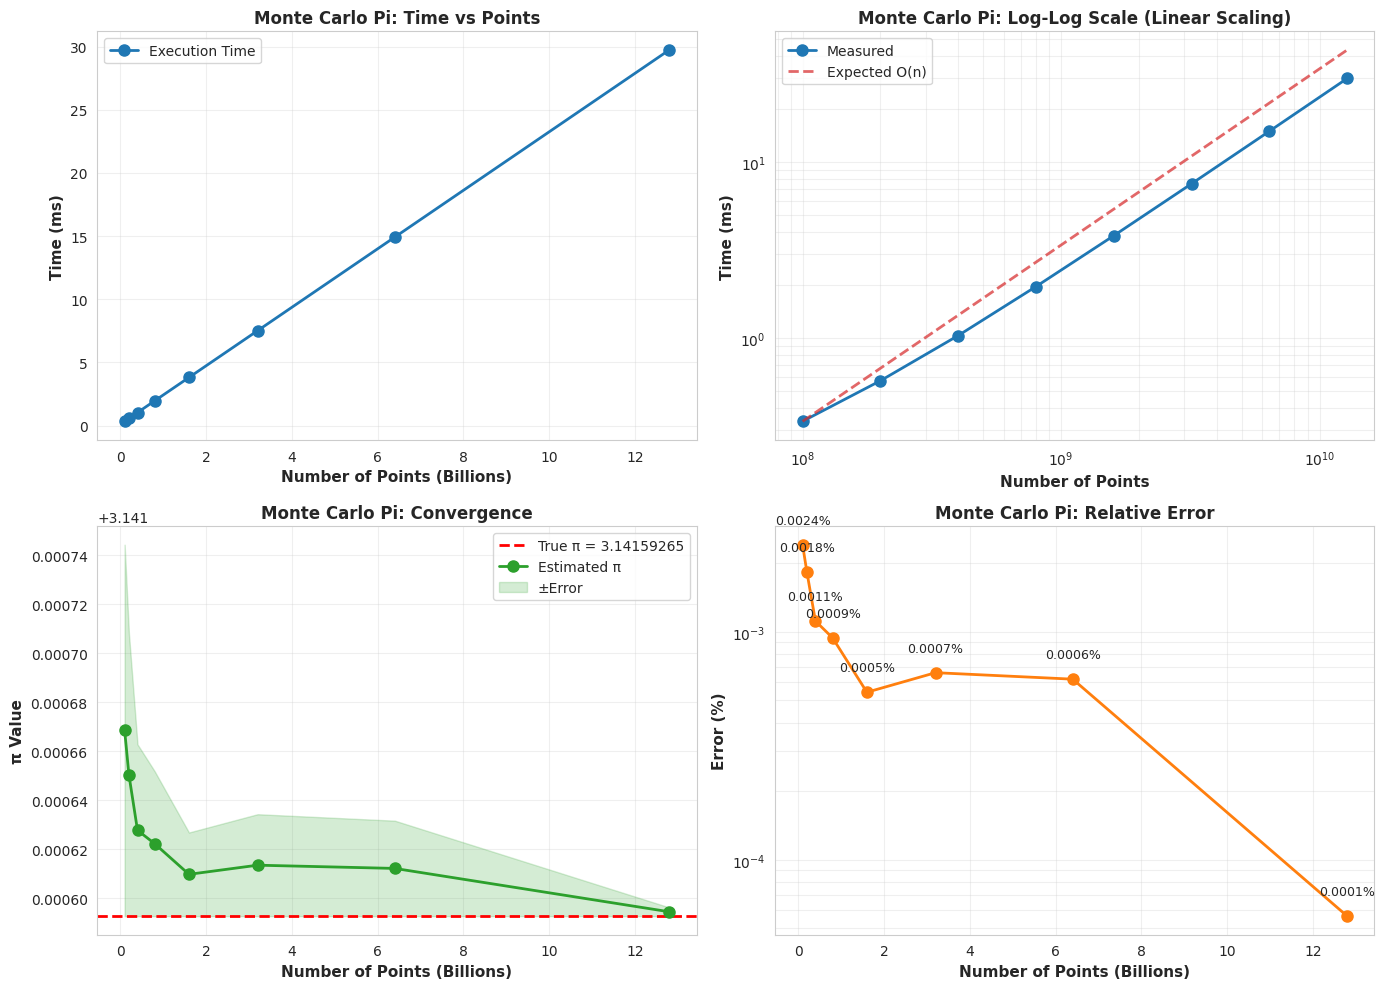

Monte Carlo Pi charts saved to 'monte_carlo_pi_analysis.png'


In [7]:
# Chart 2: Monte Carlo Pi Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time vs Points (linear scale)
ax = axes[0, 0]
ax.plot(df_pi['problem_size']/1e9, df_pi['time_ms'], 'o-', linewidth=2, markersize=8, label='Execution Time')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Time vs Points', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Log-Log scale (shows linear scaling in log space)
ax = axes[0, 1]
ax.loglog(df_pi['problem_size'], df_pi['time_ms'], 'o-', linewidth=2, markersize=8, 
          label='Measured', color='tab:blue')
# Plot expected O(n) line
n_range = np.array([df_pi['problem_size'].min(), df_pi['problem_size'].max()])
t_min = df_pi['time_ms'].iloc[0]
n_min = df_pi['problem_size'].iloc[0]
expected_linear = t_min * (n_range / n_min)
ax.loglog(n_range, expected_linear, '--', linewidth=2, label='Expected O(n)', color='tab:red', alpha=0.7)
ax.set_xlabel('Number of Points', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Log-Log Scale (Linear Scaling)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# Pi estimate convergence
ax = axes[1, 0]
ax.axhline(y=pi_true, color='red', linestyle='--', linewidth=2, label=f'True π = {pi_true:.8f}')
ax.plot(df_pi['problem_size']/1e9, df_pi['pi_estimate'], 'o-', linewidth=2, markersize=8, 
        label='Estimated π', color='tab:green')
ax.fill_between(df_pi['problem_size']/1e9, 
                 df_pi['pi_estimate'] - df_pi['pi_error'],
                 df_pi['pi_estimate'] + df_pi['pi_error'],
                 alpha=0.2, color='tab:green', label='±Error')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('π Value', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Convergence', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Error percentage
ax = axes[1, 1]
ax.semilogy(df_pi['problem_size']/1e9, df_pi['pi_error_pct'], 'o-', linewidth=2, markersize=8, 
            color='tab:orange')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('Error (%)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Relative Error', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
for i, v in enumerate(df_pi['pi_error_pct']):
    ax.text(df_pi['problem_size'].iloc[i]/1e9, v*1.2, f'{v:.4f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo_pi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monte Carlo Pi charts saved to 'monte_carlo_pi_analysis.png'")

In [6]:
# Compute derived metrics for Monte Carlo Pi
pi_true = np.pi
df_pi['pi_estimate'] = df_pi['metric1']
df_pi['pi_error'] = np.abs(df_pi['pi_estimate'] - pi_true)
df_pi['pi_error_pct'] = (df_pi['pi_error'] / pi_true) * 100
df_pi['throughput_gpts'] = df_pi['problem_size'] / (df_pi['time_ms'] * 1e6)  # Giga-points per second
df_pi['scaling_factor'] = df_pi['time_ms'] / df_pi['time_ms'].iloc[0]

print("Monte Carlo Pi - Derived Metrics:")
print(df_pi[['problem_size', 'time_ms', 'pi_estimate', 'pi_error', 'pi_error_pct', 'throughput_gpts']])

# Linear relationship analysis
print("\n" + "="*60)
print("Scaling Analysis (should be linear: O(n)):")
for i in range(1, len(df_pi)):
    size_ratio = df_pi['problem_size'].iloc[i] / df_pi['problem_size'].iloc[i-1]
    time_ratio = df_pi['time_ms'].iloc[i] / df_pi['time_ms'].iloc[i-1]
    print(f"Points: {df_pi['problem_size'].iloc[i-1]:.2e} → {df_pi['problem_size'].iloc[i]:.2e}: "
          f"time ratio={time_ratio:.3f}x (expected O(n): {size_ratio:.3f}x)")

Monte Carlo Pi - Derived Metrics:
    problem_size    time_ms  pi_estimate  pi_error  pi_error_pct  \
7      100000000   0.336896     3.141668  0.000076      0.002412   
8      200000000   0.572416     3.141650  0.000058      0.001835   
9      400000000   1.033216     3.141628  0.000035      0.001116   
10     800000000   1.959936     3.141622  0.000030      0.000941   
11    1600000000   3.810304     3.141610  0.000017      0.000543   
12    3200000000   7.512064     3.141613  0.000021      0.000662   
13    6400000000  14.918656     3.141612  0.000019      0.000620   
14   12800000000  29.731840     3.141594  0.000002      0.000057   

    throughput_gpts  
7        296.827508  
8        349.396243  
9        387.140733  
10       408.176594  
11       419.914002  
12       425.981461  
13       428.993067  
14       430.514896  

Scaling Analysis (should be linear: O(n)):
Points: 1.00e+08 → 2.00e+08: time ratio=1.699x (expected O(n): 2.000x)
Points: 2.00e+08 → 4.00e+08: time ratio=

## Section 5: Monte Carlo Pi Analysis

### Key Metrics:
- **Points**: Number of random samples generated
- **Time**: GPU kernel execution time in milliseconds
- **Pi Estimate**: Estimated value of π from hit/miss ratio
- **Accuracy**: Error from true π (3.14159265...)
- **Throughput**: Points processed per millisecond

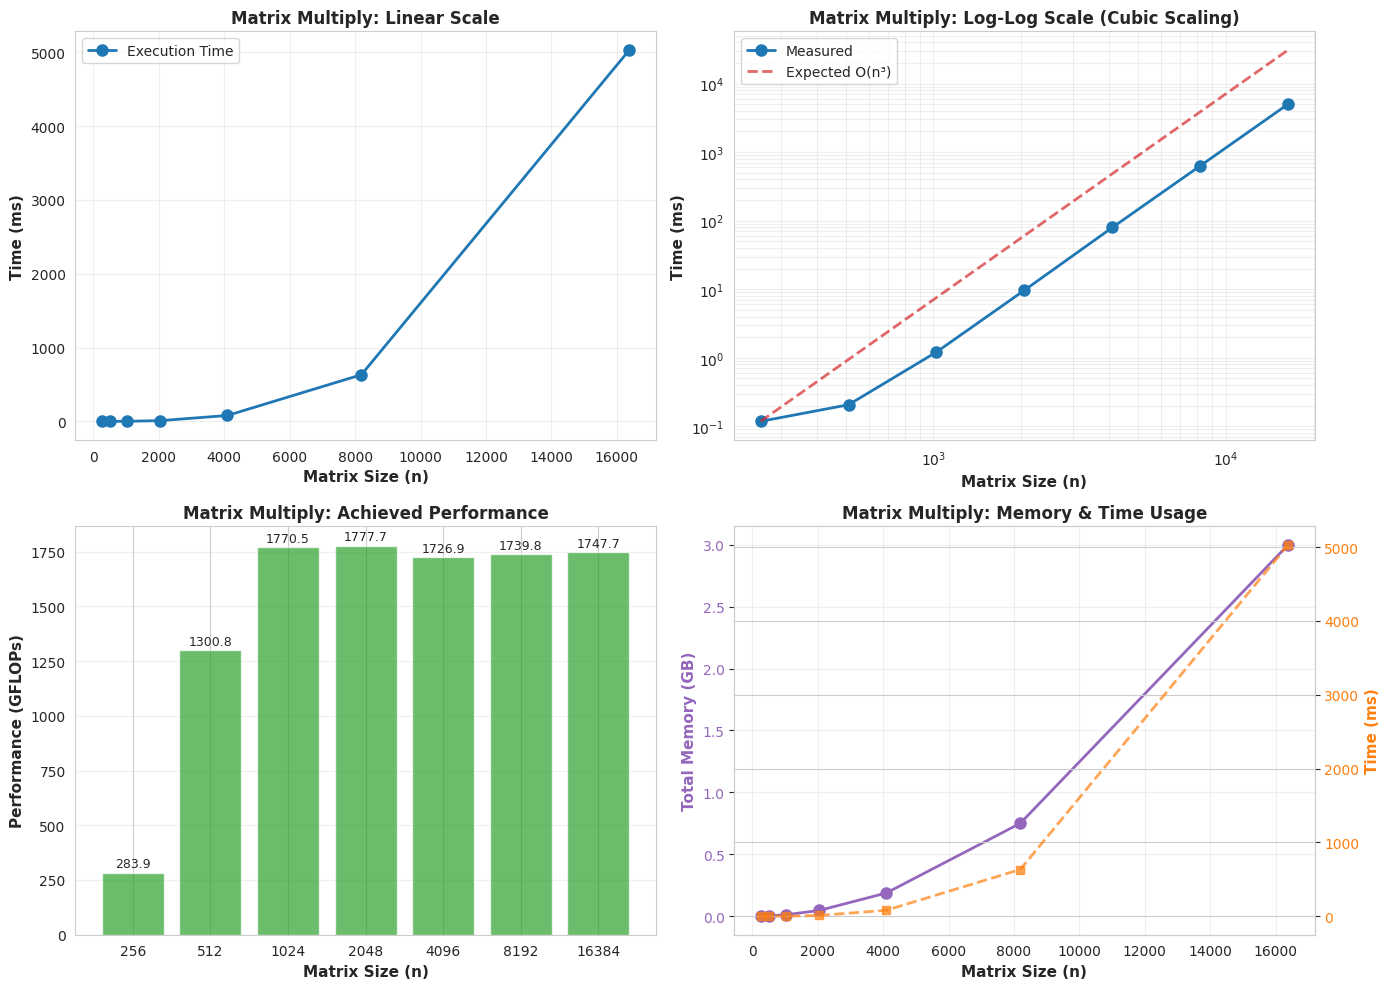

Matrix multiply charts saved to 'matrix_multiply_analysis.png'


In [5]:
# Chart 1: Linear-Linear scale time vs problem size
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear scale
ax = axes[0, 0]
ax.plot(df_matrix['problem_size'], df_matrix['time_ms'], 'o-', linewidth=2, markersize=8, label='Execution Time')
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Linear Scale', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Log-Log scale (shows cubic scaling)
ax = axes[0, 1]
ax.loglog(df_matrix['problem_size'], df_matrix['time_ms'], 'o-', linewidth=2, markersize=8, 
          label='Measured', color='tab:blue')
# Plot expected O(n³) line
n_range = np.array([df_matrix['problem_size'].min(), df_matrix['problem_size'].max()])
t_min = df_matrix['time_ms'].iloc[0]
n_min = df_matrix['problem_size'].iloc[0]
expected = t_min * (n_range / n_min) ** 3
ax.loglog(n_range, expected, '--', linewidth=2, label='Expected O(n³)', color='tab:red', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Log-Log Scale (Cubic Scaling)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# GFLOPs achieved
ax = axes[1, 0]
ax.bar(df_matrix['problem_size'].astype(str), df_matrix['gflops'], color='tab:green', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Performance (GFLOPs)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Achieved Performance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_matrix['gflops']):
    ax.text(i, v + 10, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Memory usage
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(df_matrix['problem_size'], df_matrix['memory_gb'], 'o-', linewidth=2, markersize=8, 
        label='Total Memory', color='tab:purple')
ax2.plot(df_matrix['problem_size'], df_matrix['time_ms'], 's--', linewidth=2, markersize=6, 
         label='Time', color='tab:orange', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Memory (GB)', fontsize=11, fontweight='bold', color='tab:purple')
ax2.set_ylabel('Time (ms)', fontsize=11, fontweight='bold', color='tab:orange')
ax.set_title('Matrix Multiply: Memory & Time Usage', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelcolor='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matrix_multiply_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Matrix multiply charts saved to 'matrix_multiply_analysis.png'")

In [4]:
# Compute derived metrics for matrix multiply
df_matrix['n_cubed'] = df_matrix['problem_size'] ** 3
df_matrix['memory_gb'] = (3 * df_matrix['problem_size']**2 * 4) / (1024**3)  # 3 matrices, float32
df_matrix['gflops'] = (2 * df_matrix['n_cubed']) / (df_matrix['time_ms'] * 1e6)  # GigaFLOPS
df_matrix['scaling_factor'] = df_matrix['time_ms'] / df_matrix['time_ms'].iloc[0]  # Relative to smallest

print("Matrix Multiply - Derived Metrics:")
print(df_matrix[['problem_size', 'time_ms', 'gflops', 'memory_gb', 'scaling_factor']])

# Analyze scaling behavior
print("\n" + "="*60)
print("Scaling Analysis:")
for i in range(1, len(df_matrix)):
    size_ratio = df_matrix['problem_size'].iloc[i] / df_matrix['problem_size'].iloc[i-1]
    time_ratio = df_matrix['time_ms'].iloc[i] / df_matrix['time_ms'].iloc[i-1]
    expected_cubic = size_ratio ** 3
    print(f"n: {df_matrix['problem_size'].iloc[i-1]} → {df_matrix['problem_size'].iloc[i]}: "
          f"time ratio={time_ratio:.2f}x (expected O(n³): {expected_cubic:.2f}x)")

Matrix Multiply - Derived Metrics:
   problem_size      time_ms       gflops  memory_gb  scaling_factor
0           256     0.118208   283.859231   0.000732        1.000000
1           512     0.206368  1300.761048   0.002930        1.745804
2          1024     1.212896  1770.542279   0.011719       10.260693
3          2048     9.664320  1777.659389   0.046875       81.756903
4          4096    79.586365  1726.915829   0.187500      673.273932
5          8192   631.963684  1739.833563   0.750000     5346.200629
6         16384  5033.007324  1747.681348   3.000000    42577.552484

Scaling Analysis:
n: 256 → 512: time ratio=1.75x (expected O(n³): 8.00x)
n: 512 → 1024: time ratio=5.88x (expected O(n³): 8.00x)
n: 1024 → 2048: time ratio=7.97x (expected O(n³): 8.00x)
n: 2048 → 4096: time ratio=8.24x (expected O(n³): 8.00x)
n: 4096 → 8192: time ratio=7.94x (expected O(n³): 8.00x)
n: 8192 → 16384: time ratio=7.96x (expected O(n³): 8.00x)


## Section 4: Matrix Multiply Analysis

### Key Metrics:
- **Problem Size (n)**: Matrix dimension (n×n)
- **Time**: GPU kernel execution time in milliseconds
- **Scaling**: How execution time grows with matrix size
- **Operations**: O(n³) for matrix multiplication
- **Memory**: O(n²) for each matrix

In [3]:
# Split data by benchmark type
df_matrix = df[df['benchmark'] == 'matrix_multiply'].copy().sort_values('problem_size')
df_pi = df[df['benchmark'] == 'monte_carlo_pi'].copy().sort_values('problem_size')

print("Matrix Multiply benchmarks:", len(df_matrix), "runs")
print(df_matrix[['problem_size', 'time_ms']])

print("\n" + "="*60)
print("Monte Carlo Pi benchmarks:", len(df_pi), "runs")
print(df_pi[['problem_size', 'time_ms', 'metric1']])

Matrix Multiply benchmarks: 7 runs
   problem_size      time_ms
0           256     0.118208
1           512     0.206368
2          1024     1.212896
3          2048     9.664320
4          4096    79.586365
5          8192   631.963684
6         16384  5033.007324

Monte Carlo Pi benchmarks: 8 runs
    problem_size    time_ms   metric1
7      100000000   0.336896  3.141668
8      200000000   0.572416  3.141650
9      400000000   1.033216  3.141628
10     800000000   1.959936  3.141622
11    1600000000   3.810304  3.141610
12    3200000000   7.512064  3.141613
13    6400000000  14.918656  3.141612
14   12800000000  29.731840  3.141594


## Section 3: Split Data by Benchmark

In [2]:
# Ensure numeric columns are properly typed
df['problem_size'] = pd.to_numeric(df['problem_size'])
df['gpu_count'] = pd.to_numeric(df['gpu_count'])
df['time_ms'] = pd.to_numeric(df['time_ms'])
df['metric1'] = pd.to_numeric(df['metric1'])

# Handle metric2 (may have NaN or empty values)
df['metric2'] = pd.to_numeric(df['metric2'], errors='coerce')

# Remove any fully empty rows
df = df.dropna(subset=['benchmark', 'problem_size', 'time_ms'])

print("Cleaned data shape:", df.shape)
print("\nData info after cleaning:")
print(df.info())
print("\nFirst few rows after cleaning:")
print(df.head())

Cleaned data shape: (15, 6)

Data info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   benchmark     15 non-null     object 
 1   problem_size  15 non-null     int64  
 2   gpu_count     15 non-null     int64  
 3   time_ms       15 non-null     float64
 4   metric1       15 non-null     float64
 5   metric2       8 non-null      float64
dtypes: float64(3), int64(2), object(1)
memory usage: 848.0+ bytes
None

First few rows after cleaning:
         benchmark  problem_size  gpu_count    time_ms       metric1  metric2
0  matrix_multiply           256          1   0.118208  2.013245e+08      NaN
1  matrix_multiply           512          1   0.206368  1.610604e+09      NaN
2  matrix_multiply          1024          1   1.212896  1.288488e+10      NaN
3  matrix_multiply          2048          1   9.664320  1.030792e+11      NaN
4  ma

## Section 2: Clean and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the benchmark results
csv_path = Path('benchmark_results_benchmarks_gpu_20027822.csv')
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nFirst rows:")
print(df.head(10))
print("\nColumn names and types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (15, 6)

First rows:
         benchmark  problem_size  gpu_count      time_ms       metric1  \
0  matrix_multiply           256          1     0.118208  2.013245e+08   
1  matrix_multiply           512          1     0.206368  1.610604e+09   
2  matrix_multiply          1024          1     1.212896  1.288488e+10   
3  matrix_multiply          2048          1     9.664320  1.030792e+11   
4  matrix_multiply          4096          1    79.586365  8.246337e+11   
5  matrix_multiply          8192          1   631.963684  6.597070e+12   
6  matrix_multiply         16384          1  5033.007324  5.277656e+13   
7   monte_carlo_pi     100000000          1     0.336896  3.141668e+00   
8   monte_carlo_pi     200000000          1     0.572416  3.141650e+00   
9   monte_carlo_pi     400000000          1     1.033216  3.141628e+00   

       metric2  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  
5          NaN  
6          NaN  
7   78496471.

## Section 1: Load and Inspect Data

# GPU Benchmark Analysis: Matrix Multiply vs Monte Carlo Pi

This notebook analyzes performance benchmarks from two GPU kernels run on NVIDIA Tesla V100:
- **Matrix Multiply**: Dense linear algebra computation
- **Monte Carlo Pi**: Stochastic Monte Carlo estimation

We'll examine scaling behavior, performance trends, and comparative metrics.